In [115]:
import numpy as np
import pandas as pd

In [116]:
df = pd.read_csv("https://raw.githubusercontent.com/kolomna-trams/open-data/refs/heads/main/crowd/crowd_raw.csv", parse_dates=['date'])
def convert_time_to_minutes(time_str):
    hours, minutes = time_str.split(':')
    total_minutes = int(hours) * 60 + int(minutes)
    return total_minutes

df['time'] = df['time'].apply(convert_time_to_minutes)
df = df.fillna(120)
df['date'] = pd.to_datetime(df['date'])

df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['day_of_year'] = df['date'].dt.dayofyear
df['day_mon'] = df['date'].dt.strftime('%d.%m')

# df.drop(columns=['date'], inplace=True)
df['passengers_before'] = df['passengers'] - df['inbound'] + df['outbound']
df.drop(["thunder"], axis=1, inplace=True)
df['route_percent'] = df['odometer'] / df['route_length']
df.head()

,travel_id,tram_no,weekday,date,day_of_week,precipitation,wind,temperature,route_length,stop,...,passengers,wheelchair,seating,standing,month,day,day_of_year,day_mon,passengers_before,route_percent
0,1,5,WDS,2024-09-26,THU,0,0,18,4390,0300aF,...,36,1,33,94,9,26,270,26.09,0,0.000000
1,1,5,WDS,2024-09-26,THU,0,0,18,4390,0301aF,...,41,1,33,94,9,26,270,26.09,36,0.093394
2,1,5,WDS,2024-09-26,THU,0,0,18,4390,0302aF,...,39,1,33,94,9,26,270,26.09,41,0.198178
3,1,5,WDS,2024-09-26,THU,0,0,18,4390,0303aF,...,38,1,33,94,9,26,270,26.09,39,0.261959
4,1,5,WDS,2024-09-26,THU,0,0,18,4390,0200aB,...,26,1,33,94,9,26,270,26.09,38,0.325740


Матрица корреляции

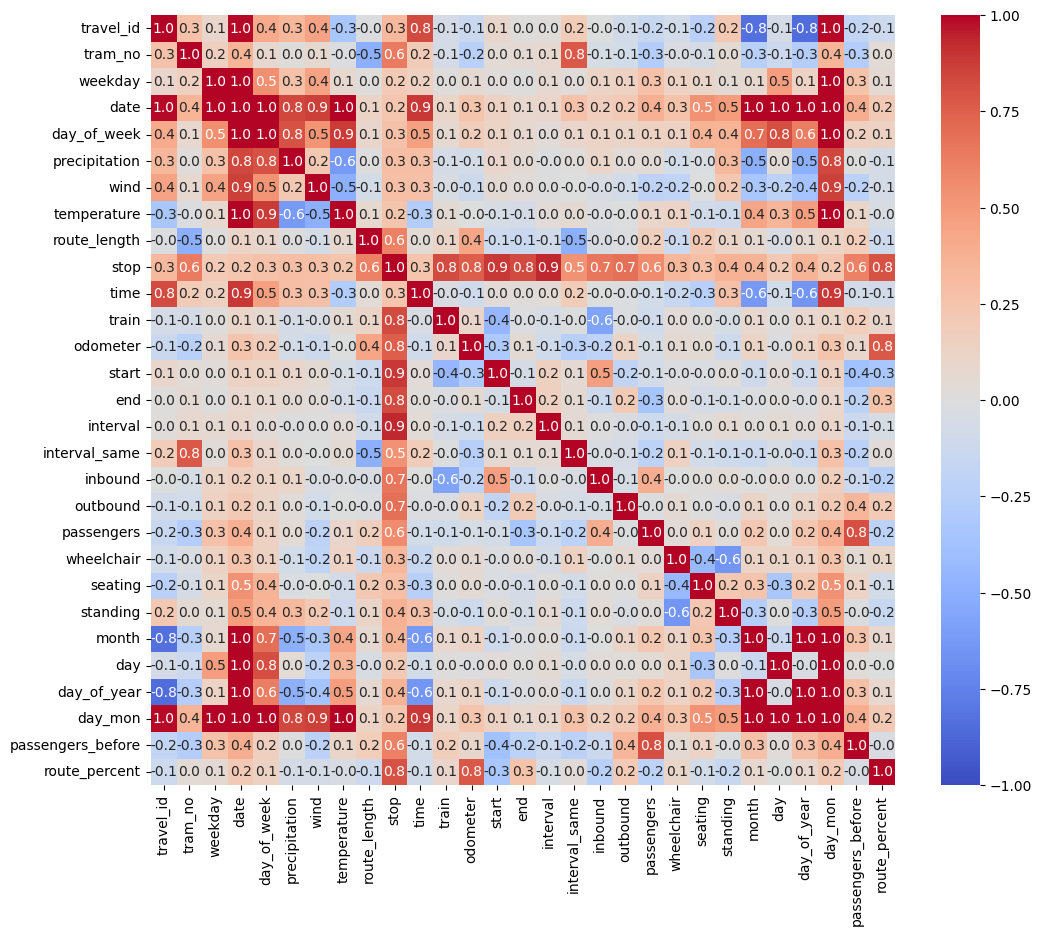

In [117]:
from scipy.stats import chi2_contingency
import seaborn as sns
import matplotlib.pyplot as plt

def cramers_v(x, y):
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    phi2 = chi2 / n
    r, k = confusion.shape
    return np.sqrt(phi2 / min(k - 1, r - 1))

def correlation_ratio(categories, values):
    categories = pd.Series(categories)
    values = pd.Series(values)
    cat_means = values.groupby(categories).mean()
    ss_between = sum(categories.value_counts() * (cat_means - values.mean())**2)
    ss_total = ((values - values.mean())**2).sum()
    return np.sqrt(ss_between / ss_total)

def mixed_corr_matrix(df):
    cols = df.columns
    n = len(cols)
    matrix = pd.DataFrame(np.ones((n, n)), index=cols, columns=cols)
    
    for i in range(n):
        for j in range(i + 1, n):
            col1, col2 = cols[i], cols[j]
            t1 = df[col1].dtype
            t2 = df[col2].dtype
            is_num1 = pd.api.types.is_numeric_dtype(t1)
            is_num2 = pd.api.types.is_numeric_dtype(t2)
            
            if is_num1 and is_num2:
                val = df[col1].corr(df[col2])
            elif not is_num1 and not is_num2:
                val = cramers_v(df[col1], df[col2])
            elif is_num1 and not is_num2:
                val = correlation_ratio(df[col2], df[col1])
            else:
                val = correlation_ratio(df[col1], df[col2])
            
            matrix.iloc[i, j] = val
            matrix.iloc[j, i] = val
    return matrix

corr_matrix = mixed_corr_matrix(df)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.1f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0)
plt.show()

In [118]:
from dataclasses import dataclass

@dataclass
class Config:
    time_col: str = 'date'
    target: str = 'passengers'
    group_cols: list = None
    season_length: int = 8
    test_days: int = 1
    random_state: int = 42
    
    def __post_init__(self):
        if self.group_cols is None:
            self.group_cols = ['tram_no', 'stop']

CONFIG = Config()

In [119]:
LEAKY_COLS = [
    'passengers_before'
]

DROP_COLS = ['date']

def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['time_sin']   = np.sin(2 * np.pi * df['time'] / 1440)
    df['time_cos']   = np.cos(2 * np.pi * df['time'] / 1440)
    df['month_sin']  = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos']  = np.cos(2 * np.pi * df['month'] / 12)
    df['doy_sin']    = np.sin(2 * np.pi * df['day_of_year'] / 365)
    df['doy_cos']    = np.cos(2 * np.pi * df['day_of_year'] / 365)
    df['is_weekend'] = df['day_of_week'].isin(['SAT', 'SUN']).astype(int)
    return df

def build_features(df: pd.DataFrame, cfg: Config):
    df = df.sort_values(['date', 'tram_no', 'travel_id', 'time']).reset_index(drop=True)
    df = add_time_features(df)

    df = df.sort_values(['travel_id', 'time'])
    for lag in [1, 2]:
        df[f'pass_lag_stop_{lag}'] = df.groupby('travel_id')[cfg.target].shift(lag)

    df = df.sort_values(['tram_no', 'stop', 'date'])
    for lag in [1, 2, 3, 7]:
        df[f'pass_lag_day_{lag}'] = (
            df.groupby(['tram_no', 'stop'])[cfg.target].shift(lag)
        )
    for win in [3, 7]:
        df[f'pass_roll_mean_{win}'] = (
            df.groupby(['tram_no', 'stop'])[cfg.target]
              .transform(lambda s: s.shift(1).rolling(win, min_periods=1).mean())
        )

    group_mean = df.groupby(['tram_no', 'stop'])[cfg.target].transform('mean')
    global_mean = df[cfg.target].mean()

    lag_cols = [c for c in df.columns
                if c.startswith('pass_lag') or c.startswith('pass_roll')]

    for c in lag_cols:
        df[c] = df[c].fillna(group_mean).fillna(global_mean)

    return df.reset_index(drop=True)

In [120]:
def time_split(df: pd.DataFrame, cfg: Config):
    dates = sorted(df['date'].unique())
    cutoff = dates[-cfg.test_days]
    train = df[df['date'] < cutoff].copy()
    test  = df[df['date'] >= cutoff].copy()
    return train, test

In [121]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def mape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate(name, y_true, y_pred):
    return {
        'Model': name,
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE':  mean_absolute_error(y_true, y_pred),
        'R2':   r2_score(y_true, y_pred),
        'MAPE': mape(y_true, y_pred),
    }

In [122]:
import pandas as pd, numpy as np
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

def get_feature_cols(df, cfg):
    drop = set(LEAKY_COLS + DROP_COLS + [cfg.target, 'date'])
    return [c for c in df.columns if c not in drop]

def _to_category(Xtr, Xte):
    Xtr, Xte = Xtr.copy(), Xte.copy()
    for c in Xtr.select_dtypes(include='object').columns:
        Xtr[c] = Xtr[c].astype('category')
        Xte[c] = pd.Categorical(Xte[c], categories=Xtr[c].cat.categories)
    return Xtr, Xte

def seasonal_naive(train, test, cfg):
    means = train.groupby(['tram_no', 'stop'])[cfg.target].mean()
    global_mean = train[cfg.target].mean()
    preds = test.apply(
        lambda r: means.get((r['tram_no'], r['stop']), global_mean), axis=1
    ).values
    return preds

def linear_regression(train, test, feats, cfg):
    Xtr = pd.get_dummies(train[feats], drop_first=True)
    Xte = pd.get_dummies(test[feats], drop_first=True).reindex(
        columns=Xtr.columns, fill_value=0
    )
    m = LinearRegression().fit(Xtr, train[cfg.target])
    return m.predict(Xte)

def random_forest(train, test, feats, cfg):
    Xtr = pd.get_dummies(train[feats], drop_first=True)
    Xte = pd.get_dummies(test[feats], drop_first=True).reindex(
        columns=Xtr.columns, fill_value=0
    )
    m = RandomForestRegressor(n_estimators=500, n_jobs=-1,
                              random_state=cfg.random_state)
    m.fit(Xtr, train[cfg.target])
    return m.predict(Xte)

def lightgbm_model(train, test, feats, cfg):
    Xtr, Xte = _to_category(train[feats], test[feats])
    m = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.03,
                          num_leaves=63, random_state=cfg.random_state, verbose=-1)
    m.fit(Xtr, train[cfg.target],
          eval_set=[(Xte, test[cfg.target])],
          callbacks=[lgb.early_stopping(100, verbose=False)])
    return m.predict(Xte)

def catboost_model(train, test, feats, cfg):
    Xtr = train[feats].copy()
    Xte = test[feats].copy()

    cat_feats = []
    for c in Xtr.columns:
        if Xtr[c].dtype.name in ('object', 'category'):
            Xtr[c] = Xtr[c].astype(str).fillna('NA')
            Xte[c] = Xte[c].astype(str).fillna('NA')
            cat_feats.append(c)

    m = CatBoostRegressor(
        iterations=1000,
        learning_rate=0.05,
        depth=5,
        l2_leaf_reg=5,
        random_seed=cfg.random_state,
        verbose=False,
    )
    m.fit(
        Xtr, train[cfg.target],
        cat_features=cat_feats,
        eval_set=(Xte, test[cfg.target]),
        early_stopping_rounds=100,
    )
    return m.predict(Xte)

def _to_category(Xtr, Xte):
    Xtr, Xte = Xtr.copy(), Xte.copy()
    for c in Xtr.select_dtypes(include='object').columns:
        Xtr[c] = Xtr[c].astype('category')
        Xte[c] = pd.Categorical(Xte[c], categories=Xtr[c].cat.categories)
    return Xtr, Xte

In [123]:
import numpy as np, pandas as pd
import pytorch_lightning as pl
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import RMSE as TFT_RMSE

def build_tft_dataset(df, cfg, max_encoder=28, max_pred=8):
    df = df.copy()
    df['series_id'] = df['travel_id'].astype(str)
    df['time_idx'] = df.groupby('series_id').cumcount()

    df['tram_no'] = df['tram_no'].astype(str)
    df['travel_id'] = df['travel_id'].astype(str)
    df['series_id'] = df['series_id'].astype(str)
    df['weekday'] = df['weekday'].astype(str)
    df['day_of_week'] = df['day_of_week'].astype(str)
    df['stop'] = df['stop'].astype(str)

    for c in LEAKY_COLS + ['date', 'day_mon']:
        if c in df.columns:
            df = df.drop(columns=c)

    known_reals = [
        'time_idx', 'time', 'time_sin', 'time_cos',
        'month_sin', 'month_cos', 'doy_sin', 'doy_cos',
        'is_weekend', 'temperature', 'precipitation', 'wind',
    ]
    known_reals = [c for c in known_reals if c in df.columns]

    training = TimeSeriesDataSet(
        df,
        time_idx='time_idx',
        target=cfg.target,
        group_ids=['series_id'],
        max_encoder_length=max_encoder,
        max_prediction_length=max_pred,
        time_varying_known_reals=known_reals,
        time_varying_unknown_reals=[cfg.target],
        static_categoricals=['tram_no'],
        target_normalizer=GroupNormalizer(groups=['series_id']),
        allow_missing_timesteps=True,
    )
    return training, df


def train_tft(train_df, test_df, cfg, max_epochs=50):
    training, df_all = build_tft_dataset(train_df, cfg)
    validation = TimeSeriesDataSet.from_dataset(
        training, pd.concat([train_df, test_df]).assign(
            series_id=lambda d: d['tram_no'].astype(str) + '_' + d['stop'].astype(str),
            time_idx=lambda d: d.groupby(lambda i: d.loc[i, 'tram_no'].astype(str) + '_' + d.loc[i, 'stop'].astype(str)).cumcount()
        ),
        predict=True, stop_randomization=True
    )
    train_dl = training.to_dataloader(train=True,  batch_size=64, num_workers=0)
    val_dl   = validation.to_dataloader(train=False, batch_size=64, num_workers=0)

    tft = TemporalFusionTransformer.from_dataset(
        training, learning_rate=0.01, hidden_size=64,
        attention_head_size=4, dropout=0.1,
        hidden_continuous_size=32, loss=TFT_RMSE(),
    )
    trainer = pl.Trainer(max_epochs=max_epochs, accelerator='auto',
                         enable_progress_bar=False, logger=False)
    trainer.fit(tft, train_dataloaders=train_dl, val_dataloaders=val_dl)

    preds = tft.predict(val_dl, mode='prediction', return_x=True)
    return preds.output.cpu().numpy().flatten()

In [124]:
import numpy as np
import pandas as pd
import torch
from torch_geometric.data import Data

def build_stop_graph(df: pd.DataFrame):
    stops = sorted(df['stop'].unique())
    stop2idx = {s: i for i, s in enumerate(stops)}

    edges = set()

    for tid, grp in df.sort_values('time').groupby('travel_id'):
        seq = grp['stop'].tolist()
        for a, b in zip(seq[:-1], seq[1:]):
            i, j = stop2idx[a], stop2idx[b]
            edges.add((i, j)); edges.add((j, i))

    stop_to_routes = df.groupby('stop')['tram_no'].unique()
    for s, routes in stop_to_routes.items():
        if len(routes) > 1:
            for r1 in routes:
                for r2 in routes:
                    if r1 != r2:
                        pass

    edge_index = torch.tensor(list(edges), dtype=torch.long).t().contiguous()

    node_feats = df.groupby('stop')[
        ['temperature', 'precipitation', 'wind', 'route_length']
    ].mean().reindex(stops).fillna(0).values

    x = torch.tensor(node_feats, dtype=torch.float)
    data = Data(x=x, edge_index=edge_index)
    return data, stop2idx

In [125]:
import torch, torch.nn as nn
from torch_geometric.nn import GCNConv

class GNNEncoder(nn.Module):
    def __init__(self, in_dim, hid_dim):
        super().__init__()
        self.gcn1 = GCNConv(in_dim, hid_dim)
        self.gcn2 = GCNConv(hid_dim, hid_dim)
    def forward(self, x, edge_index):
        x = torch.relu(self.gcn1(x, edge_index))
        return self.gcn2(x, edge_index)

In [126]:
def main(df):
    cfg = CONFIG
    df = build_features(df, cfg)
    train, test = time_split(df, cfg)
    feats = get_feature_cols(df, cfg)

    y_test = test[cfg.target].values
    results = []

    results.append(evaluate('SeasonalNaive',    y_test, seasonal_naive(train, test, cfg)))
    results.append(evaluate('LinearRegression', y_test, linear_regression(train, test, feats, cfg)))
    results.append(evaluate('RandomForest',     y_test, random_forest(train, test, feats, cfg)))
    results.append(evaluate('LightGBM',         y_test, lightgbm_model(train, test, feats, cfg)))
    results.append(evaluate('CatBoost',         y_test, catboost_model(train, test, feats, cfg)))

    # from models_tft import train_tft
    #tft_pred = train_tft(train, test, cfg)
    #results.append(evaluate('TFT', y_test[:len(tft_pred)], tft_pred))

    report = pd.DataFrame(results).set_index('Model').round(3).sort_values('RMSE')
    print(report)
    report.to_csv('model_comparison.csv')
    return report

In [127]:
main(df)

                   RMSE    MAE     R2    MAPE
Model                                        
CatBoost          2.674  1.785  0.920  18.324
LightGBM          2.693  1.679  0.919  17.186
RandomForest      2.720  1.871  0.917  19.631
LinearRegression  7.620  7.420  0.352  84.232
SeasonalNaive     9.370  7.005  0.020  58.531


,RMSE,MAE,R2,MAPE
Model,,,,
CatBoost,2.674,1.785,0.920,18.324
LightGBM,2.693,1.679,0.919,17.186
RandomForest,2.720,1.871,0.917,19.631
LinearRegression,7.620,7.420,0.352,84.232
SeasonalNaive,9.370,7.005,0.020,58.531
